# Pokemonika: Pokemon Classification with Transfer Learning

Goal: classify the Pokemon name from a given Pokemon image. This notebook contains the full homework workflow: dataset loading, 4 transfer-learning experiments, test precision/recall comparison, learning curves, model saving, and GUI instructions.

## 1. Setup

Run this install cell once if the required packages are missing.

In [1]:
# !pip install torch torchvision streamlit scikit-learn matplotlib numpy pillow pandas

In [2]:
from copy import deepcopy
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

DATA_DIR = Path('PokemonData')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
IMAGE_SIZE = 224
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## 2. Dataset Check

The dataset is already extracted as `PokemonData/`. The zip file can be kept as backup, but training uses the folder because `ImageFolder` expects one class folder per label.

In [3]:
class_folders = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])
image_files = [p for p in DATA_DIR.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}]
print('Classes:', len(class_folders))
print('Images:', len(image_files))
print('First 10 classes:', [p.name for p in class_folders[:10]])

Classes: 150
Images: 6820
First 10 classes: ['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise']


## 3. Experiment Settings

At least 4 classifier settings are required. These experiments compare backbone model and fine-tuning range.

| Experiment | Backbone | Pretrained | Fine-tuning |
| --- | --- | --- | --- |
| `resnet18_frozen` | ResNet-18 | Yes | classifier head only |
| `resnet18_finetune` | ResNet-18 | Yes | all layers |
| `mobilenet_v3_frozen` | MobileNetV3-Small | Yes | classifier head only |
| `efficientnet_b0_frozen` | EfficientNet-B0 | Yes | classifier head only |

In [4]:
def train_transform():
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def eval_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def build_model(architecture, num_classes, pretrained=True, freeze_backbone=True):
    if architecture == 'resnet18':
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if architecture == 'mobilenet_v3_small':
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model

    if architecture == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model

    raise ValueError(architecture)

## 4. Train/Validation/Test Split

The split is stratified so every Pokemon class is represented fairly in train, validation, and test sets.

In [5]:
base_dataset = ImageFolder(DATA_DIR)
indices = np.arange(len(base_dataset.samples))
labels = np.array(base_dataset.targets)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=labels[temp_idx])

train_dataset = Subset(ImageFolder(DATA_DIR, transform=train_transform()), train_idx)
val_dataset = Subset(ImageFolder(DATA_DIR, transform=eval_transform()), val_idx)
test_dataset = Subset(ImageFolder(DATA_DIR, transform=eval_transform()), test_idx)
class_names = base_dataset.classes

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset), len(test_dataset), len(class_names)

(4774, 1023, 1023, 150)

## 5. Training and Evaluation Functions

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

@torch.inference_mode()
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for images, labels in loader:
        logits = model(images.to(device))
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(logits.argmax(1).cpu().numpy().tolist())
    return y_true, y_pred

def plot_learning_curve(history, title, out_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='validation')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='validation')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()

def train_one_experiment(config):
    exp_dir = ARTIFACT_DIR / config['name']
    exp_dir.mkdir(exist_ok=True)
    model = build_model(config['architecture'], len(class_names), config['pretrained'], config['freeze_backbone']).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=config['lr'], weight_decay=1e-4)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = deepcopy(model.state_dict())
    best_val_acc = 0.0
    start = time.time()

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"{config['name']} epoch {epoch}/{config['epochs']} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    (exp_dir / 'classification_report.txt').write_text(report, encoding='utf-8')
    json.dump(history, open(exp_dir / 'history.json', 'w'), indent=2)
    plot_learning_curve(history, config['name'], exp_dir / 'learning_curve.png')

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'config': config,
    }
    torch.save(checkpoint, exp_dir / 'model.pth')

    return {
        'name': config['name'],
        'architecture': config['architecture'],
        'pretrained': config['pretrained'],
        'freeze_backbone': config['freeze_backbone'],
        'best_val_accuracy': best_val_acc,
        'test_accuracy': float(np.mean(np.array(y_true) == np.array(y_pred))),
        'test_macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'test_macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'test_weighted_precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'test_weighted_recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'seconds': round(time.time() - start, 2),
    }

## 6. Run the 4 Experiments

For a quick check, set `epochs` to 1. For the final submission, use more epochs such as 6 or 10.

resnet18_frozen epoch 1/6 train_acc=0.2160 val_acc=0.4907
resnet18_frozen epoch 2/6 train_acc=0.6565 val_acc=0.6882
resnet18_frozen epoch 3/6 train_acc=0.7922 val_acc=0.7195
resnet18_frozen epoch 4/6 train_acc=0.8471 val_acc=0.7576
resnet18_frozen epoch 5/6 train_acc=0.8904 val_acc=0.7849
resnet18_frozen epoch 6/6 train_acc=0.9072 val_acc=0.7752


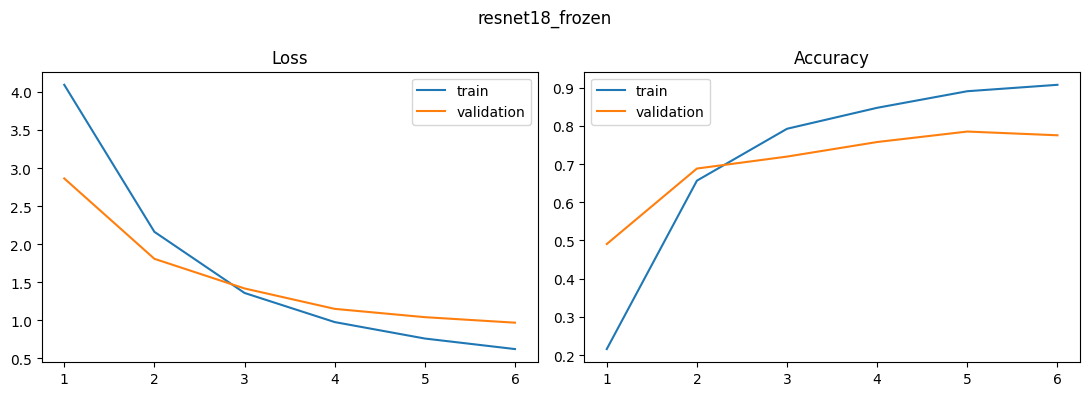

resnet18_finetune epoch 1/6 train_acc=0.4076 val_acc=0.7801
resnet18_finetune epoch 2/6 train_acc=0.8798 val_acc=0.9130
resnet18_finetune epoch 3/6 train_acc=0.9608 val_acc=0.9423
resnet18_finetune epoch 4/6 train_acc=0.9803 val_acc=0.9492
resnet18_finetune epoch 5/6 train_acc=0.9872 val_acc=0.9472
resnet18_finetune epoch 6/6 train_acc=0.9910 val_acc=0.9501


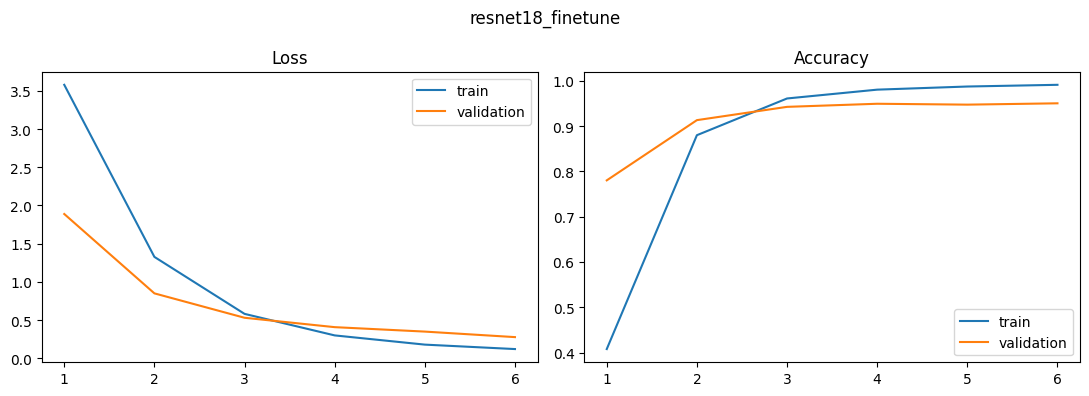

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\felio/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 11.3MB/s]


mobilenet_v3_frozen epoch 1/6 train_acc=0.4043 val_acc=0.6882
mobilenet_v3_frozen epoch 2/6 train_acc=0.7717 val_acc=0.7517
mobilenet_v3_frozen epoch 3/6 train_acc=0.8483 val_acc=0.7644
mobilenet_v3_frozen epoch 4/6 train_acc=0.8779 val_acc=0.7752
mobilenet_v3_frozen epoch 5/6 train_acc=0.9039 val_acc=0.7849
mobilenet_v3_frozen epoch 6/6 train_acc=0.9202 val_acc=0.7859


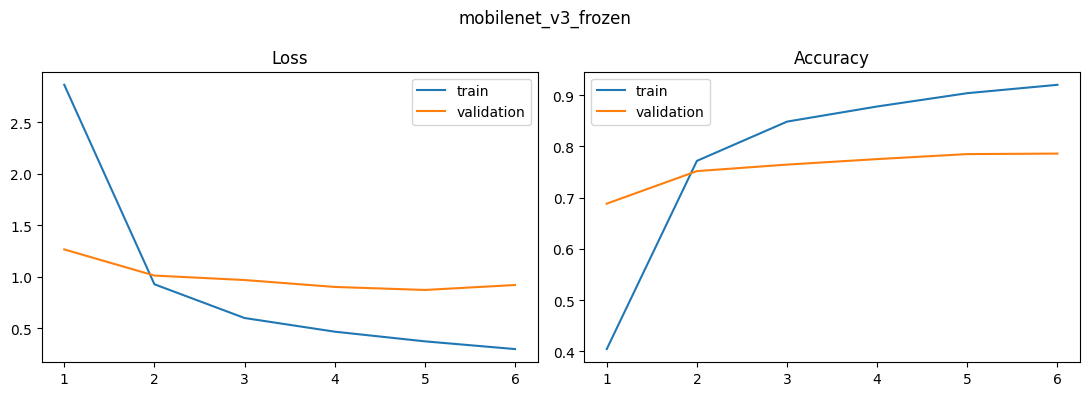

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\felio/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 10.9MB/s]


efficientnet_b0_frozen epoch 1/6 train_acc=0.3354 val_acc=0.6188
efficientnet_b0_frozen epoch 2/6 train_acc=0.7518 val_acc=0.6911
efficientnet_b0_frozen epoch 3/6 train_acc=0.8433 val_acc=0.7429
efficientnet_b0_frozen epoch 4/6 train_acc=0.8781 val_acc=0.7458
efficientnet_b0_frozen epoch 5/6 train_acc=0.8951 val_acc=0.7634
efficientnet_b0_frozen epoch 6/6 train_acc=0.9187 val_acc=0.7664


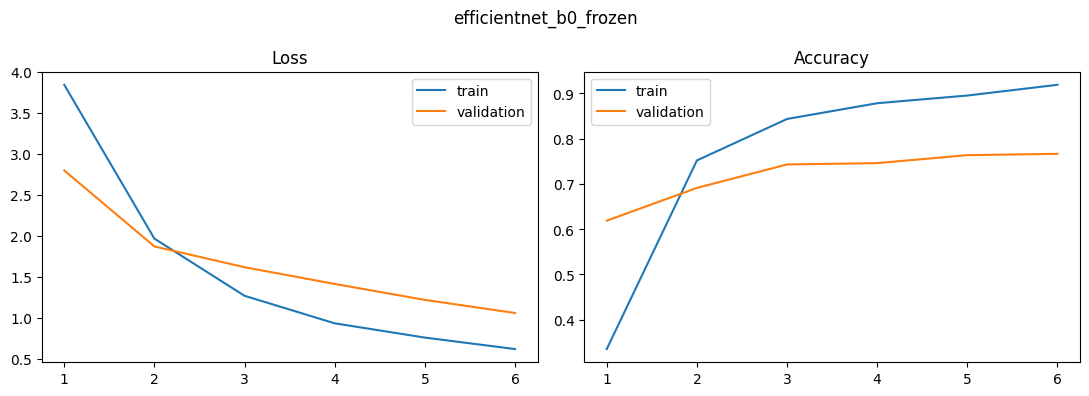

,name,architecture,pretrained,freeze_backbone,best_val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,test_weighted_precision,test_weighted_recall,seconds
1,resnet18_finetune,resnet18,True,False,0.950147,0.948192,0.953090,0.945243,0.956076,0.948192,1470.99
3,efficientnet_b0_frozen,efficientnet_b0,True,True,0.766373,0.787879,0.809826,0.779280,0.811441,0.787879,632.73
0,resnet18_frozen,resnet18,True,True,0.784946,0.786901,0.813197,0.781238,0.815685,0.786901,661.07
2,mobilenet_v3_frozen,mobilenet_v3_small,True,True,0.785924,0.771261,0.826691,0.765460,0.828360,0.771261,300.54


In [7]:
experiments = [
    {'name': 'resnet18_frozen', 'architecture': 'resnet18', 'pretrained': True, 'freeze_backbone': True, 'lr': 1e-3, 'epochs': 6},
    {'name': 'resnet18_finetune', 'architecture': 'resnet18', 'pretrained': True, 'freeze_backbone': False, 'lr': 1e-4, 'epochs': 6},
    {'name': 'mobilenet_v3_frozen', 'architecture': 'mobilenet_v3_small', 'pretrained': True, 'freeze_backbone': True, 'lr': 1e-3, 'epochs': 6},
    {'name': 'efficientnet_b0_frozen', 'architecture': 'efficientnet_b0', 'pretrained': True, 'freeze_backbone': True, 'lr': 1e-3, 'epochs': 6},
]

results = []
for config in experiments:
    results.append(train_one_experiment(config))

metrics = pd.DataFrame(results).sort_values('test_weighted_recall', ascending=False)
metrics.to_csv(ARTIFACT_DIR / 'metrics.csv', index=False)
metrics

## 7. Save Best Model for GUI

In [8]:
best_name = metrics.iloc[0]['name']
best_model_path = ARTIFACT_DIR / best_name / 'model.pth'
(ARTIFACT_DIR / 'best_model.pth').write_bytes(best_model_path.read_bytes())
print('Best experiment:', best_name)
print('Saved GUI model to:', ARTIFACT_DIR / 'best_model.pth')

Best experiment: resnet18_finetune
Saved GUI model to: artifacts\best_model.pth


## 9. Run GUI Demo

After `artifacts/best_model.pth` is created, run this in a terminal from the `Pokemonika` folder:

```bash
streamlit run gui.py
```

The GUI supports drag-and-drop or upload of a Pokemon image and displays the top predicted Pokemon names with confidence values.